In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
#clean and inspect data
print(df.shape)
print(df.isnull().sum().sum())   # should be 0
print(df.dtypes.value_counts())
print(df.duplicated().sum())     # check for duplicate rows

(284807, 31)
0
float64    30
int64       1
Name: count, dtype: int64
1081


In [3]:
df = df.drop_duplicates()

In [5]:
#check the class balance -------------------
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True) * 100)

Class
0    283253
1       473
Name: count, dtype: int64
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


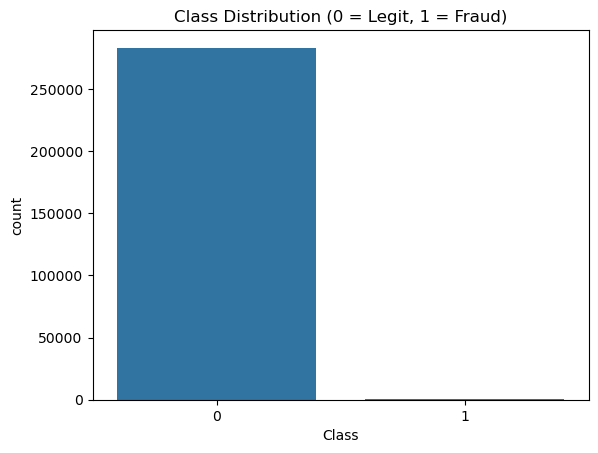

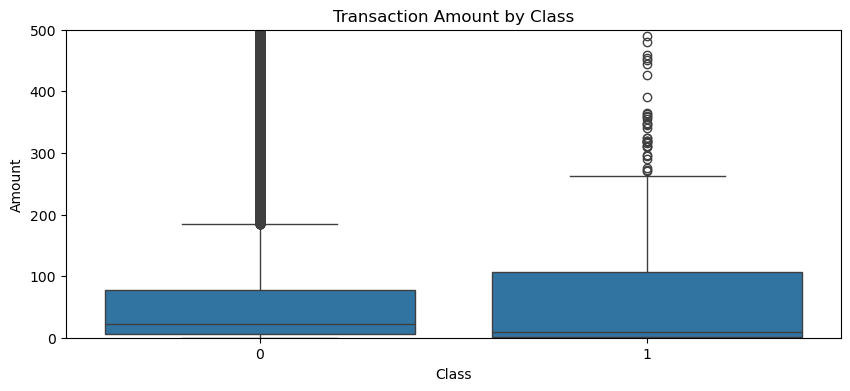

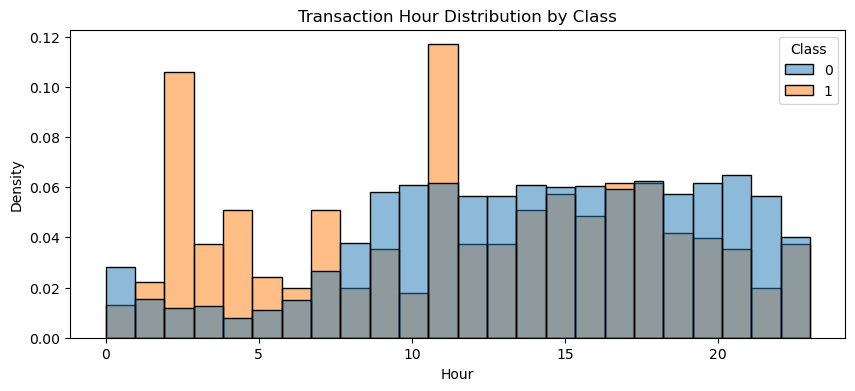

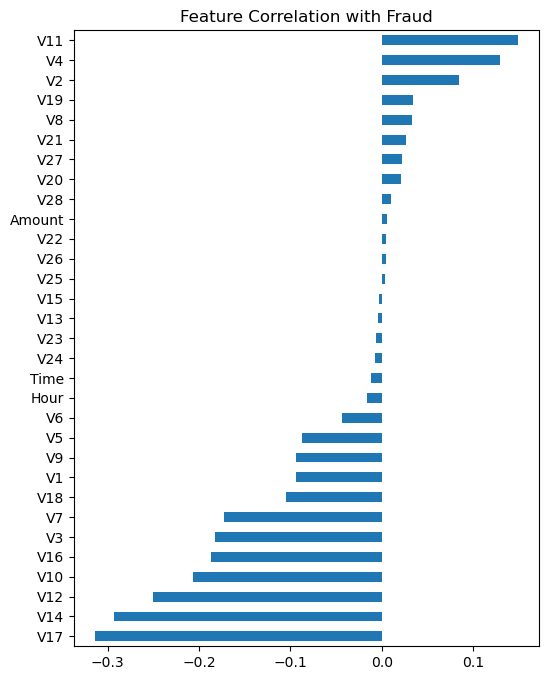

In [6]:
#data analysis
# Class imbalance, visually
sns.countplot(data=df, x='Class')
plt.title('Class Distribution (0 = Legit, 1 = Fraud)')
plt.show()

# Transaction amount: fraud vs legit
plt.figure(figsize=(10,4))
sns.boxplot(data=df, x='Class', y='Amount')
plt.ylim(0, 500)  # zoom in, most amounts are small
plt.title('Transaction Amount by Class')
plt.show()

# Time of day patterns (Time is seconds elapsed since the first transaction)
df['Hour'] = (df['Time'] // 3600) % 24
plt.figure(figsize=(10,4))
sns.histplot(data=df, x='Hour', hue='Class', bins=24, stat='density', common_norm=False)
plt.title('Transaction Hour Distribution by Class')
plt.show()

# Correlation of V-features with the target
corr = df.corr()['Class'].drop('Class').sort_values()
corr.plot(kind='barh', figsize=(6,8))
plt.title('Feature Correlation with Fraud')
plt.show()

In [7]:
#feature engineering

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])

# Time as hour-of-day (cyclical) is more informative than raw seconds elapsed
df['Hour'] = (df['Time'] // 3600) % 24

# Drop the raw columns we've replaced
df = df.drop(columns=['Time', 'Amount'])

In [8]:
#splitting features and targets
X = df.drop(columns=['Class'])
y = df['Class']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [9]:
#handling imbalance
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=0.5, random_state=42)  # bring fraud up to 50% of legit count in training data only
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(y_train_res.value_counts())

Class
0    226602
1    113301
Name: count, dtype: int64


In [10]:
#training and comparing models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_res, y_train_res)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_res, y_train_res)

xgb_model = XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1)
xgb_model.fit(X_train_res, y_train_res)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [11]:
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

results = {}
for name, model in [('Logistic Regression', log_model), ('Random Forest', rf_model), ('XGBoost', xgb_model)]:
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, probs)
    pr_auc = average_precision_score(y_test, probs)
    print(f"--- {name} ---")
    print(classification_report(y_test, preds, digits=4))
    print("ROC-AUC:", round(roc_auc, 4))
    print("PR-AUC:", round(pr_auc, 4))
    print()
    results[name] = {'roc_auc': roc_auc, 'pr_auc': pr_auc}

--- Logistic Regression ---
              precision    recall  f1-score   support

           0     0.9998    0.9872    0.9935     56651
           1     0.1030    0.8737    0.1842        95

    accuracy                         0.9870     56746
   macro avg     0.5514    0.9305    0.5889     56746
weighted avg     0.9983    0.9870    0.9921     56746

ROC-AUC: 0.9641
PR-AUC: 0.6543

--- Random Forest ---
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9997     56651
           1     0.9012    0.7684    0.8295        95

    accuracy                         0.9995     56746
   macro avg     0.9504    0.8841    0.9146     56746
weighted avg     0.9994    0.9995    0.9995     56746

ROC-AUC: 0.9653
PR-AUC: 0.8052

--- XGBoost ---
              precision    recall  f1-score   support

           0     0.9997    0.9997    0.9997     56651
           1     0.8085    0.8000    0.8042        95

    accuracy                         0.9993     5674

In [12]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
}

search = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=20,
    scoring='average_precision',   # optimize for PR-AUC, not accuracy
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
search.fit(X_train_res, y_train_res)

print("Best params:", search.best_params_)
best_model = search.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.2, 'colsample_bytree': 0.8}


In [13]:
preds = best_model.predict(X_test)
probs = best_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, probs)
pr_auc = average_precision_score(y_test, probs)

print(classification_report(y_test, preds, digits=4))
print("ROC-AUC:", round(roc_auc, 4))
print("PR-AUC:", round(pr_auc, 4))

              precision    recall  f1-score   support

           0     0.9996    0.9998    0.9997     56651
           1     0.8721    0.7895    0.8287        95

    accuracy                         0.9995     56746
   macro avg     0.9359    0.8946    0.9142     56746
weighted avg     0.9994    0.9995    0.9994     56746

ROC-AUC: 0.9769
PR-AUC: 0.8081


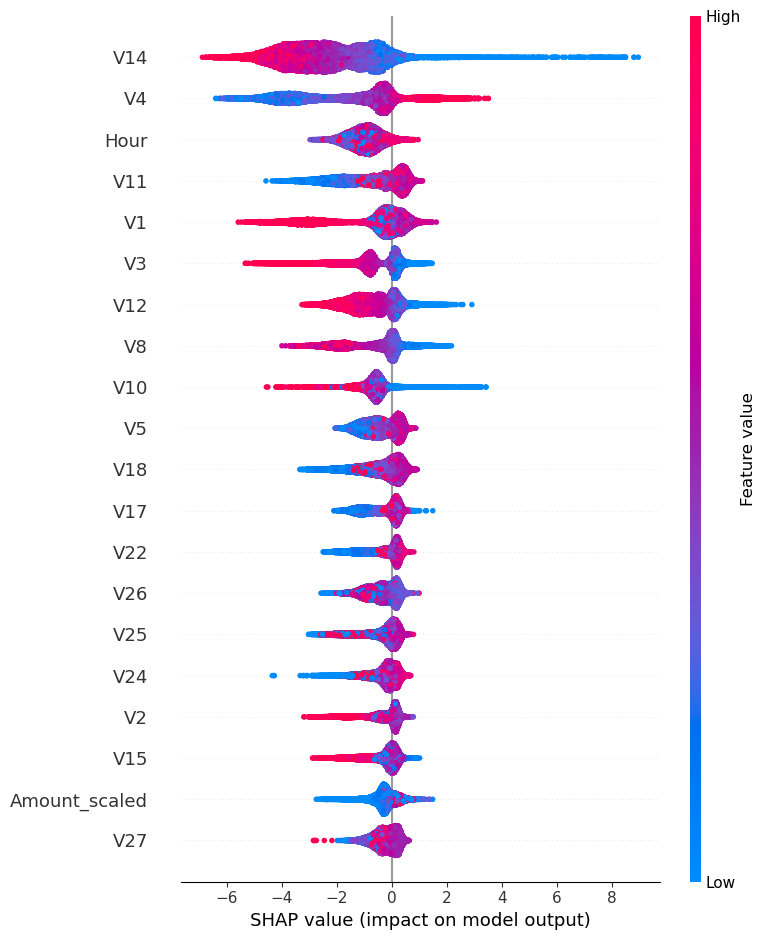

In [14]:
#SHAP

import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

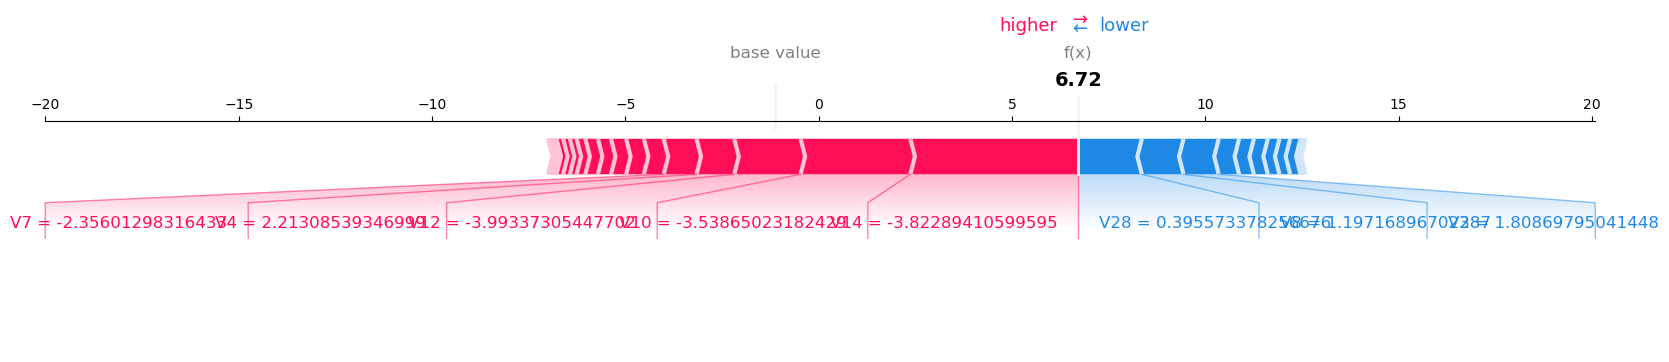

In [15]:
fraud_idx = y_test[y_test == 1].index[0]
shap.force_plot(
    explainer.expected_value,
    shap_values[X_test.index.get_loc(fraud_idx)],
    X_test.loc[fraud_idx],
    matplotlib=True
)

In [16]:
#saving best model
import joblib

joblib.dump(best_model, 'fraud_model.pkl')
joblib.dump(scaler, 'scaler.pkl')   # the StandardScaler fit on Amount in Step 3

['scaler.pkl']

In [17]:
!pip freeze > requirements.txt

In [19]:
#if u want to run app with sampple example
# Grab one real fraud row and one real legit row from your test set
fraud_row = X_test[y_test == 1].iloc[0]
legit_row = X_test[y_test == 0].iloc[0]

print("FRAUD example:")
print(', '.join(map(str, fraud_row.values)))
print()
print("LEGIT example:")
print(', '.join(map(str, legit_row.values)))

FRAUD example:
-1.54878809850026, 1.80869795041448, -0.953509033832342, 2.21308539346999, -2.01572779170327, -0.913456844516923, -2.35601298316433, 1.19716896702387, -1.67837405659509, -3.53865023182429, 3.1020899271543, -3.99337305447702, -1.93741062327519, -3.82289410599595, 0.830970110708369, -2.47535885382925, -5.21187516766885, -0.413871678166879, 0.933262164554872, 0.390785963777347, 0.855138263312025, 0.77474482148342, 0.0590371520063436, 0.343199807900813, -0.468937928609185, -0.278337986906642, 0.625922215184372, 0.395573378256676, 20.0, -0.046057242650085206

LEGIT example:
1.2288211502379, -0.0634077165201056, 0.274145142235826, 0.647465021810117, -0.0481345611508765, 0.372073028593297, -0.22423058741343, 0.0799390492455152, 0.640758817066441, -0.273053702248503, -1.25272793883718, 0.465078770741453, 0.400502115321077, -0.292841860600363, -0.10177401599731, -0.399835897844616, 0.0343356567914817, -0.783550254934187, 0.141344900433949, -0.0965659023514416, -0.129554448055005,